# One Farm, One Picture — first hour

**Not a solution.** The technique here is **checking the data before trusting it**,
which sounds like housekeeping and is actually the whole challenge.

The brief says so directly: *"Strong entries surface data quality rather than hiding
it behind a clean-looking chart."* This corpus contains real, unannounced defects.
Every one of them produces a plausible chart if you skip this step.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from lib.loader import load
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ch = load('c01-one-farm-one-picture')
for c in ch.caveats():
    print('CAVEAT:', c[:150])
ch

CAVEAT: field_daily: Daily field-level NDVI and soil moisture, with the nearest weather station. SYNTHETIC stand-in for the intended CEDA/Defra join. NDVI is 
CAVEAT: station_weather: Station observations. SYNTHETIC stand-in for MIDAS Open, and deliberately UNCLEANED — despite what an earlier description claimed. Co


<Challenge c01-one-farm-one-picture (field_daily=180,000, station_weather=913,500)>

In [2]:
ch.describe('station_weather')

,name,type,description
0,station_id,string,Station identifier.
1,observation_date,date,"Observation day, ISO-8601. NOT unique with sta..."
2,county,string,County the station sits in.
3,latitude,double,"Latitude, WGS84."
4,longitude,double,"Longitude, WGS84."
5,temp_max_c,double,"Daily maximum, Celsius. Three stations carry a..."
6,temp_min_c,double,"Daily minimum, Celsius."
7,rainfall_mm,double,"Daily rainfall, mm."
8,quality_flag,string,'ok' or 'suspect'. Carries only the defects a ...


## Step 1 — is the grain what it claims?

Always the first question, and it takes one line. A table that is not unique on its
stated key will inflate every aggregate you build on it, and nothing downstream will
look wrong.

In [3]:
w = ch.tables['station_weather']

print(f'rows          {len(w):,}')
print(f'stations      {w.station_id.nunique():,}')
print(f'days          {w.observation_date.nunique():,}')
print(f'expected      {w.station_id.nunique() * w.observation_date.nunique():,}')

dupes = w.duplicated(['station_id','observation_date'], keep=False)
print(f'\nDUPLICATE station-days: {dupes.sum():,} rows  ({dupes.sum()/len(w):.1%})')

rows          913,500
stations      250
days          3,600
expected      900,000

DUPLICATE station-days: 27,000 rows  (3.0%)


### The quality flag will not save you

There is a `quality_flag` column. The obvious move is to filter on it. Check what it
actually catches before you rely on it.

In [4]:
print(w.quality_flag.value_counts().to_string())
print()
clean = w[w.quality_flag == 'ok']
still = clean.duplicated(['station_id','observation_date']).sum()
print(f"after WHERE quality_flag = 'ok', duplicates remaining: {still:,}")
print()
print('The flag carries the defects an ingest pipeline WOULD have caught.')
print('The ones it missed are the ones still here.')

quality_flag
ok         913360
suspect       140



after WHERE quality_flag = 'ok', duplicates remaining: 13,500

The flag carries the defects an ingest pipeline WOULD have caught.
The ones it missed are the ones still here.


## Step 2 — what does the duplication cost you?

Quantify the error before deciding whether to care. Sometimes it is negligible.
Here it is not, and the direction is not obvious in advance.

In [5]:
naive = w.temp_max_c.mean()
deduped = w.drop_duplicates(['station_id','observation_date']).temp_max_c.mean()
print(f'mean temp_max, naive     : {naive:.3f} C')
print(f'mean temp_max, de-duped  : {deduped:.3f} C')
print(f'difference               : {naive - deduped:+.3f} C')
print()
print('Small on the mean — but duplicates are not spread evenly, so any')
print('per-station or per-month figure is distorted unevenly too.')

mean temp_max, naive     : 14.763 C
mean temp_max, de-duped  : 14.765 C
difference               : -0.002 C

Small on the mean — but duplicates are not spread evenly, so any
per-station or per-month figure is distorted unevenly too.


## Step 3 — find the sensors that stopped working

A stuck sensor is not null and not absurd. It reports the same value for days, which
survives every range check and quietly drags any average toward the frozen number.
The technique is **run-length detection**: look for repetition, not for outliers.

In [6]:
def longest_flat_run(s):
    runs, cur, best = 0, 1, 1
    v = s.values
    for i in range(1, len(v)):
        cur = cur + 1 if v[i] == v[i-1] else 1
        best = max(best, cur)
    return best

clean = w.drop_duplicates(['station_id','observation_date']).sort_values('observation_date')
runs = clean.groupby('station_id').temp_max_c.apply(longest_flat_run).sort_values(ascending=False)

print('Longest run of identical temp_max per station:')
print(runs.head(8).to_string())
print()
print(f'median across all stations: {runs.median():.0f} days  <- natural repetition at 1dp')
print(f'stations far above that   : {(runs >= 15).sum()}')

Longest run of identical temp_max per station:
station_id
S-0166    21
S-0024    21
S-0213    21
S-0175    21
S-0075     3
S-0184     3
S-0185     3
S-0186     3

median across all stations: 2 days  <- natural repetition at 1dp
stations far above that   : 4


## Step 4 — find the miscalibrated stations

This one cannot be found by looking at a station on its own: a constant offset is
internally consistent. It only appears **by comparison with neighbours**, which is the
transferable idea — for systematic error, compare like with like.

In [7]:
county_mean = clean.groupby('county').temp_max_c.transform('mean')
clean = clean.assign(dev = clean.temp_max_c - county_mean)
offset = clean.groupby(['station_id','county']).dev.mean().sort_values(ascending=False)

print('Mean deviation from county average (top and bottom):')
print(offset.head(5).to_string())
print('...')
print(offset.tail(3).to_string())

Mean deviation from county average (top and bottom):
station_id  county        
S-0034      Rutland           3.530390
S-0084      Hertfordshire     3.374723
S-0074      Leicestershire    2.973354
S-0011      Cambridgeshire    1.081310
S-0040      Hertfordshire     1.054195
...
station_id  county        
S-0211      Rutland          -1.181221
S-0214      Leicestershire   -1.194480
S-0116      Rutland          -1.358638


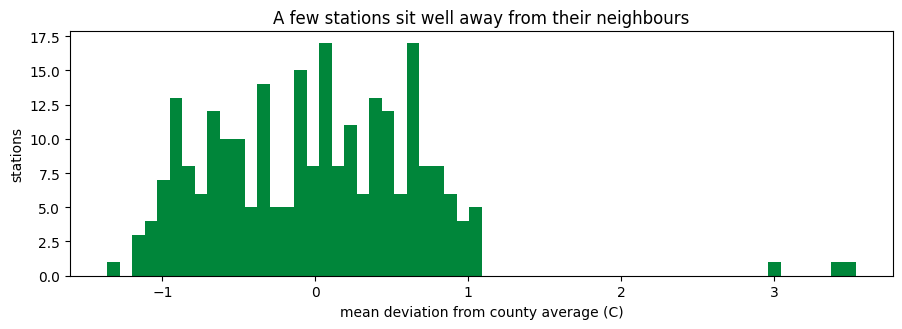

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(offset.values, bins=60, color='#00863a')
ax.set_xlabel('mean deviation from county average (C)')
ax.set_ylabel('stations')
ax.set_title('A few stations sit well away from their neighbours')
plt.tight_layout(); plt.show()

## Step 5 — the missing data is not missing at random

This is the subtlest defect and the one most likely to reach a final presentation
undetected. NDVI is absent on about a fifth of field-days because cloud blocks optical
satellite readings — and **cloud sits over a field for days at a time**.

So the gaps come in runs, which means `dropna()` does not give you a smaller unbiased
sample. It gives you a sample of **clear weather**, which is hotter and drier than
average. Any model fitted on what survives has been silently conditioned on that.

In [9]:
f = ch.tables['field_daily']
print(f'NDVI missing: {f.ndvi.isna().mean():.1%} of field-days')

one = f[f.field_id == f.field_id.iloc[0]].sort_values('observation_date')
gaps, cur = [], 0
for missing in one.ndvi.isna():
    if missing: cur += 1
    elif cur: gaps.append(cur); cur = 0
if cur: gaps.append(cur)
print(f'gap lengths for one field: {gaps}')
print()
print('Runs, not scatter. If the gaps were random, these would almost all be 1.')

NDVI missing: 20.9% of field-days
gap lengths for one field: [6, 12, 10, 18, 11, 11, 2, 9]

Runs, not scatter. If the gaps were random, these would almost all be 1.


In [10]:
# What does dropping them actually change? Join to weather and compare.
joined = f.merge(clean[['station_id','observation_date','temp_max_c']],
                 left_on=['nearest_station_id','observation_date'],
                 right_on=['station_id','observation_date'], how='left')

kept = joined[joined.ndvi.notna()].temp_max_c.mean()
lost = joined[joined.ndvi.isna()].temp_max_c.mean()
print(f'mean temp on days NDVI survives : {kept:.2f} C')
print(f'mean temp on days NDVI is gone  : {lost:.2f} C')
print(f'difference                      : {kept - lost:+.2f} C')

mean temp on days NDVI survives : 15.84 C
mean temp on days NDVI is gone  : 10.48 C
difference                      : +5.35 C


## Step 6 — the join is weaker than it looks

`nearest_station_id` invites a clean join. But *nearest* varies from under 1km to 28km,
and a temperature reading 28km away is a much weaker proxy than one next door.
Nothing in the data warns you — the column is just as populated either way.

In [11]:
d = f.groupby('field_id').distance_to_station_km.first()
print(d.describe().to_string())
print()
print(f'fields more than 15km from their station: {(d > 15).sum()} of {len(d)} ({(d>15).mean():.0%})')
print()
print('Consider weighting by distance, or excluding the far ones and saying so.')

count    500.000000
mean      14.424480
std        7.937054
min        0.850000
25%        7.727500
50%       14.030000
75%       21.452500
max       27.980000

fields more than 15km from their station: 232 of 500 (46%)

Consider weighting by distance, or excluding the far ones and saying so.


## Where to go next

- Fix the duplicates first — every later number depends on it.
- Decide what to do about the stuck and miscalibrated stations, and **write the
  decision down**. Dropping them is defensible; silently keeping them is not.
- If you impute NDVI, say what you assumed. The gaps are informative, not noise.
- `market_prices` is not in this build: its source (`ahdb`) has not cleared licence
  review, so it ships as a pointer rather than as data.